<a href="https://colab.research.google.com/github/hanzalaakeel/NIAI_Cohort_2026/blob/main/NETSOL_AI_ML_Tasks/Distribution_Group_Task/Distribution_Group_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set aesthetics for plots
sns.set_theme(style="whitegrid")

# Load the dataset
# Ensure 'athlete_events.csv' is in your Colab file explorer
df = pd.read_csv('/content/athlete_events.csv', on_bad_lines='skip')

# Quick inspection
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (271116, 15)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [3]:
# Create a binary column: 1 if a medal was won, 0 otherwise
df['Has_Medal'] = df['Medal'].notnull().astype(int)

# Filter for relevant columns
df_clean = df[['ID', 'Sex', 'Age', 'Height', 'Weight', 'NOC', 'Year', 'Has_Medal']].copy()

In [4]:
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (271116, 16)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,Has_Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,1
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,0


Bernoulli Probability (p) of winning a medal: 0.1467

Exact counts: 
No Medal (0): 231333 entries
Medal (1): 39783 entries


/tmp/ipykernel_5142/4015633622.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Has_Medal', data=df_clean, palette="viridis")


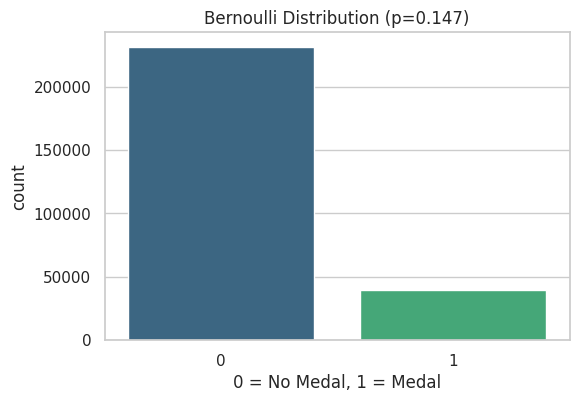

In [ ]:
# Create a binary column: 1 if a medal was won, 0 otherwise (if not already done)
df['Has_Medal'] = df['Medal'].notnull().astype(int)

# Filter for relevant columns (re-defining df_clean to ensure it exists)
df_clean = df[['ID', 'Sex', 'Age', 'Height', 'Weight', 'NOC', 'Year', 'Has_Medal']].copy()

# Calculate probability of success (p)
p_bernoulli = df_clean['Has_Medal'].mean()
print(f"Bernoulli Probability (p) of winning a medal: {p_bernoulli:.4f}")

# Count exact number of No Medal and Medal entries
medal_counts = df_clean['Has_Medal'].value_counts()
print(f"\nExact counts: \nNo Medal (0): {medal_counts.get(0, 0)} entries\nMedal (1): {medal_counts.get(1, 0)} entries")

# Visualization
plt.figure(figsize=(6, 4))
sns.countplot(x='Has_Medal', data=df_clean, palette="viridis")
plt.title(f'Bernoulli Distribution (p={p_bernoulli:.3f})')
plt.xlabel('0 = No Medal, 1 = Medal')
plt.show()

Average number of medals per group of 20 athletes: 2.88
First 10 sample counts of medals in groups: [np.int64(2), np.int64(4), np.int64(2), np.int64(3), np.int64(3), np.int64(4), np.int64(6), np.int64(2), np.int64(5), np.int64(0)]


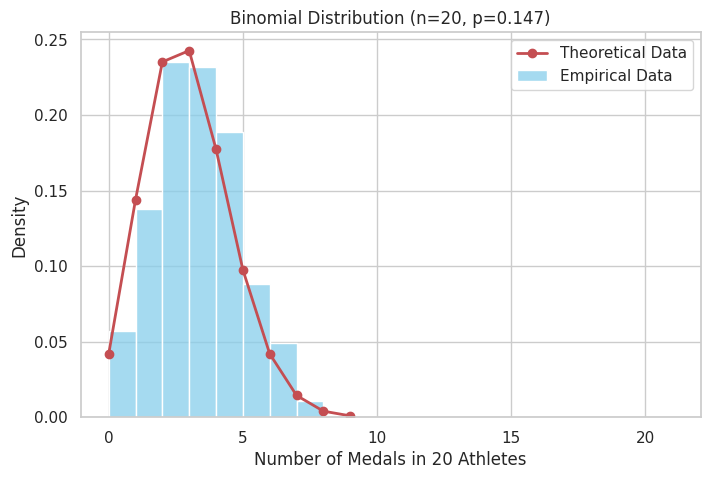

In [ ]:
n_trials = 20
# Simulate 1000 groups of 20 athletes
binomial_samples = [df_clean['Has_Medal'].sample(n_trials).sum() for _ in range(1000)]

print(f"Average number of medals per group of {n_trials} athletes: {np.mean(binomial_samples):.2f}")
print(f"First 10 sample counts of medals in groups: {binomial_samples[:10]}")

plt.figure(figsize=(8, 5))
sns.histplot(binomial_samples, bins=range(n_trials+2), stat="density", color="skyblue", label='Empirical Data')

x_bin = np.arange(0, 10)
plt.plot(x_bin, stats.binom.pmf(x_bin, n_trials, p_bernoulli), 'ro-', lw=2, label='Theoretical Data')
plt.title(f'Binomial Distribution (n={n_trials}, p={p_bernoulli:.3f})')
plt.xlabel('Number of Medals in 20 Athletes')
plt.legend()
plt.show()

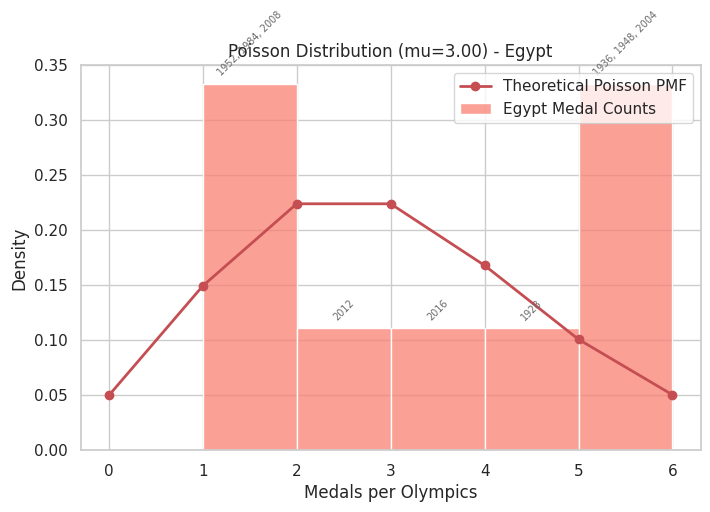

In [ ]:
# Get medals count for Egypt per year
egy_medals = df_clean[(df_clean['NOC'] == 'EGY') & (df_clean['Has_Medal'] == 1)].groupby('Year').size()
mu_poisson = egy_medals.mean()

plt.figure(figsize=(8, 5))
ax = sns.histplot(egy_medals, bins=range(int(egy_medals.max())+2), stat="density", color="salmon", label='Egypt Medal Counts')

# Overlay theoretical PMF
x_pois = np.arange(0, egy_medals.max()+2)
plt.plot(x_pois, stats.poisson.pmf(x_pois, mu_poisson), 'ro-', lw=2, label='Theoretical Poisson PMF')

plt.title(f'Poisson Distribution (mu={mu_poisson:.2f}) - Egypt')
plt.xlabel('Medals per Olympics')
plt.legend()

# Add year annotations to the bars
for bar in ax.patches:
    x_pos = bar.get_x() + bar.get_width() / 2  # Center of the bar
    height = bar.get_height()

    # Get the medal count corresponding to this bar
    medal_count_for_bar = int(bar.get_x() + 0.5)

    # Find all years from egy_medals that have this specific medal_count
    years_for_this_count = egy_medals[egy_medals == medal_count_for_bar].index.tolist()

    if years_for_this_count and height > 0: # Only annotate if there's a bar and years
        # Format years for display
        years_str = ', '.join(map(lambda y: str(int(y)), sorted(years_for_this_count)))

        # Add the annotation text
        # Adjust y-position slightly above the bar
        ax.text(x_pos, height + 0.005, years_str, ha='center', va='bottom', fontsize=7, color='dimgrey', rotation=45)

plt.show()

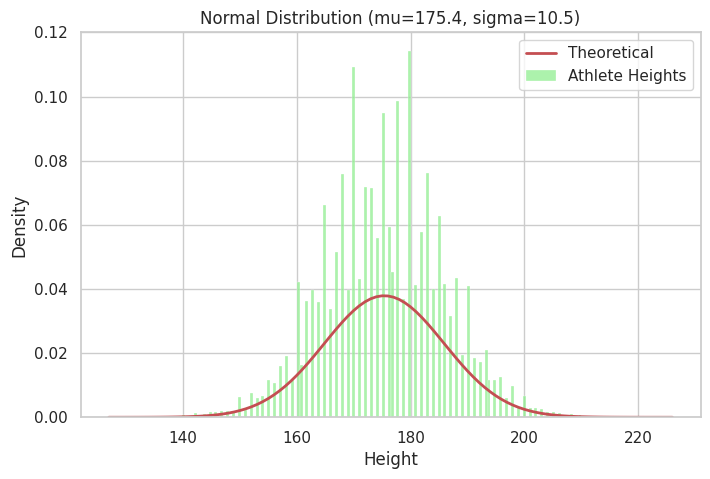

In [ ]:
heights = pd.to_numeric(df_clean['Height'], errors='coerce').dropna()
mu_norm, std_norm = heights.mean(), heights.std()

plt.figure(figsize=(8, 5))
sns.histplot(heights, kde=False, stat="density", color="lightgreen", label='Athlete Heights')

x_norm = np.linspace(heights.min(), heights.max(), 100)
plt.plot(x_norm, stats.norm.pdf(x_norm, mu_norm, std_norm), 'r-', lw=2, label='Theoretical')
plt.title(f'Normal Distribution (mu={mu_norm:.1f}, sigma={std_norm:.1f})')
plt.legend()
plt.show()

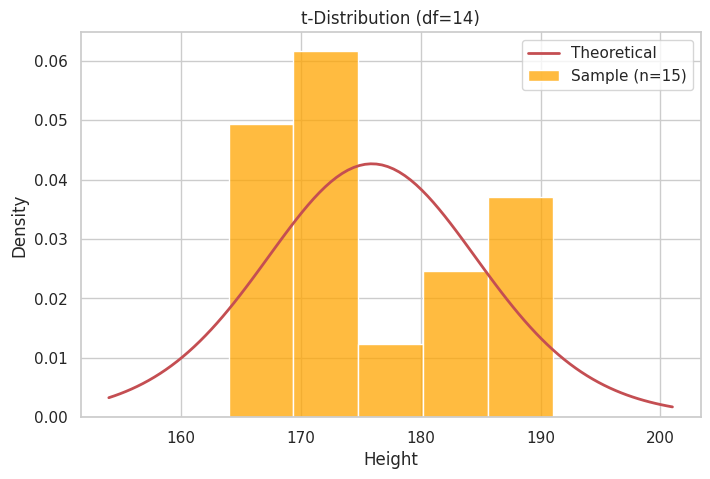

In [ ]:
small_sample = heights.sample(15, random_state=42)
df_t = len(small_sample) - 1

plt.figure(figsize=(8, 5))
sns.histplot(small_sample, stat="density", color="orange", label='Sample')

x_t = np.linspace(small_sample.min()-10, small_sample.max()+10, 100)
plt.plot(x_t, stats.t.pdf(x_t, df_t, loc=small_sample.mean(), scale=small_sample.std()), 'r-', lw=2, label='Theoretical')
plt.title(f"t-Distribution (df={df_t})")
plt.legend()
plt.show()

0.2


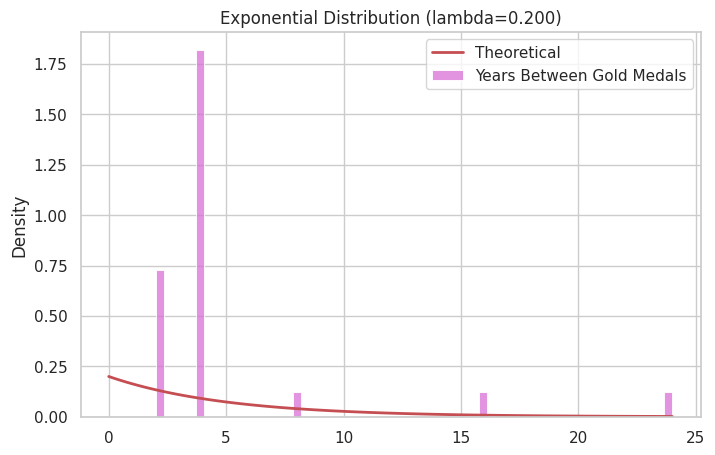

In [ ]:
aus_gold = df_clean[(df_clean['NOC'] == 'AUS') & (df['Medal'] == 'Gold')].sort_values('Year')['Year'].unique()
inter_medal_years = np.diff(aus_gold)
lambda_exp = 1 / inter_medal_years.mean()
print(lambda_exp)
plt.figure(figsize=(8, 5))
sns.histplot(inter_medal_years, stat="density", color="orchid", label='Years Between Gold Medals')
# Overlay PDF
x_exp = np.linspace(0, inter_medal_years.max(), 100)
plt.plot(x_exp, stats.expon.pdf(x_exp, scale=1/lambda_exp), 'r-', lw=2, label='Theoretical')
plt.title(f'Exponential Distribution (lambda={lambda_exp:.3f})')
plt.legend()
plt.show()

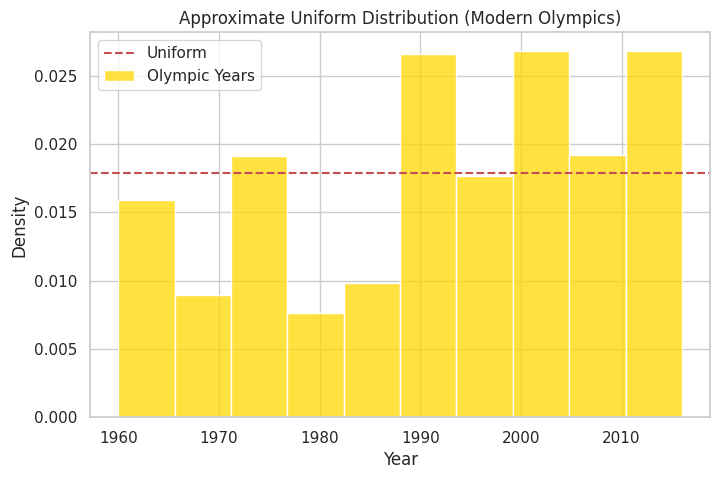

In [ ]:
modern_years = df_clean[df_clean['Year'] >= 1960]['Year']

plt.figure(figsize=(8, 5))
sns.histplot(modern_years, bins=10, stat="density", color="gold", label='Olympic Years')
# Overlay Uniform PDF
plt.axhline(1/(modern_years.max() - modern_years.min()), color='r', linestyle='--', label='Uniform')
plt.title('Approximate Uniform Distribution (Modern Olympics)')
plt.legend()
plt.show()

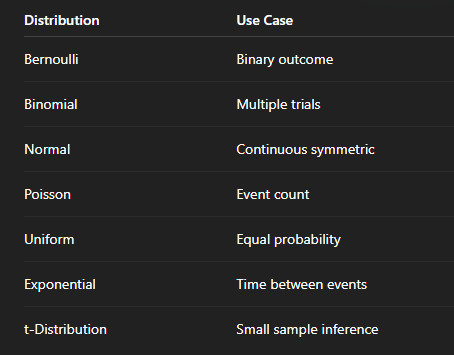